In [23]:
from sys import displayhook
%reload_ext autoreload
%autoreload 2
%matplotlib inline
import pandas as pd
import numpy as np
import seaborn as sns
np.random.seed(721)

In [24]:
dataframe = pd.read_csv("test_data.csv", index_col=0)
print(dataframe)

                            File   Status    Runtime  Runlength  quality  seed
0       ./storage/default7/1.txt    UNSAT   966.8330          0        0    -1
1       ./storage/default7/4.txt    UNSAT   178.4680          0        0    -1
2       ./storage/default7/5.txt    UNSAT    85.3295          0        0    -1
3       ./storage/default7/6.txt    UNSAT  1647.0200          0        0    -1
4       ./storage/default7/7.txt    UNSAT  1521.0100          0        0    -1
..                           ...      ...        ...        ...      ...   ...
178  ./storage/default7/1856.txt  SUCCESS    36.2545          0        0    -1
179  ./storage/default7/1857.txt  SUCCESS  2084.8800          0        0    -1
180  ./storage/default7/1858.txt  SUCCESS   371.6770          0        0    -1
181  ./storage/default7/1869.txt  SUCCESS   149.1110          0        0    -1
182  ./storage/default7/1881.txt  SUCCESS    32.7798          0        0    -1

[183 rows x 6 columns]


In [25]:
train = []

with open("./aclib2/instances/mip/sets/SDPdMLPa-MIPVerify/training.txt") as file:
    line = file.readline()
    while line:
        number = line.split("/")[-1][4:-4]
        train.append(f"./storage/default7/{number}.txt")
        line = file.readline()
    file.close()

print(train)
train_dataframe = dataframe[dataframe["File"].isin(train)]
display(train_dataframe)

['./storage/default7/1.txt', './storage/default7/4.txt', './storage/default7/5.txt', './storage/default7/6.txt', './storage/default7/7.txt', './storage/default7/11.txt', './storage/default7/12.txt', './storage/default7/13.txt', './storage/default7/14.txt', './storage/default7/15.txt', './storage/default7/18.txt', './storage/default7/20.txt', './storage/default7/21.txt', './storage/default7/22.txt', './storage/default7/23.txt', './storage/default7/24.txt', './storage/default7/26.txt', './storage/default7/27.txt', './storage/default7/28.txt', './storage/default7/29.txt', './storage/default7/30.txt', './storage/default7/31.txt', './storage/default7/32.txt', './storage/default7/33.txt', './storage/default7/35.txt', './storage/default7/34.txt', './storage/default7/63.txt', './storage/default7/64.txt', './storage/default7/93.txt', './storage/default7/116.txt', './storage/default7/120.txt', './storage/default7/134.txt', './storage/default7/145.txt', './storage/default7/152.txt', './storage/de

,File,Status,Runtime,Runlength,quality,seed
0,./storage/default7/1.txt,UNSAT,966.8330,0,0,-1
1,./storage/default7/4.txt,UNSAT,178.4680,0,0,-1
2,./storage/default7/5.txt,UNSAT,85.3295,0,0,-1
3,./storage/default7/6.txt,UNSAT,1647.0200,0,0,-1
4,./storage/default7/7.txt,UNSAT,1521.0100,0,0,-1
...,...,...,...,...,...,...
112,./storage/default7/884.txt,SUCCESS,114.2630,0,0,-1
113,./storage/default7/891.txt,SUCCESS,71.0128,0,0,-1
114,./storage/default7/899.txt,SUCCESS,22.6034,0,0,-1
115,./storage/default7/901.txt,SUCCESS,1290.0000,0,0,-1


count      92.000000
mean     1148.551835
std      2089.521849
min         6.082770
25%        55.294725
50%       243.361500
75%      1344.075000
max      9601.170000
Name: Runtime, dtype: float64
Status
SUCCESS    66
UNSAT      23
TIMEOUT     3
Name: count, dtype: int64


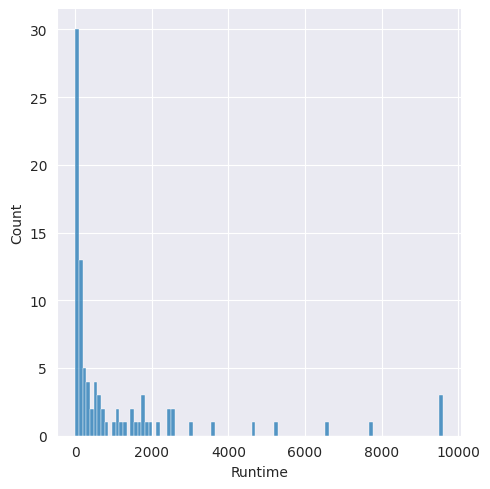

In [26]:
sns.displot(train_dataframe, x="Runtime", bins=100)
print(train_dataframe["Runtime"].describe())
print(train_dataframe["Status"].value_counts())

In [27]:
pick_probs = train_dataframe["Runtime"] / train_dataframe["Runtime"].sum()
# pick_probs

In [62]:
np.random.seed(721)
# samples = np.random.choice(train_dataframe["File"], size=5, p=pick_probs)
print(len(train_dataframe))
samples = np.random.choice(np.arange(len(train_dataframe)), size=30, p=pick_probs, replace=False)
print(f"Samples: {samples}")

92
Samples: [ 6 22 82 65  8 33  4 13 76 20 50 57 45 31 49 56 60 18  7 59 14  9  3 44
 40  0 71 10 61 90]


In [65]:
small_dataset = train_dataframe.iloc[samples]
display(small_dataset.head())

,File,Status,Runtime,Runlength,quality,seed
6,./storage/default7/12.txt,UNSAT,6557.540,0,0,-1
22,./storage/default7/32.txt,UNSAT,1949.510,0,0,-1
107,./storage/default7/830.txt,SUCCESS,3056.590,0,0,-1
90,./storage/default7/566.txt,SUCCESS,565.623,0,0,-1
8,./storage/default7/14.txt,TIMEOUT,9601.170,0,0,-1


count      30.000000
mean     2733.520333
std      3013.681392
min       102.997000
25%       429.602250
50%      1714.335000
75%      3500.222500
max      9601.170000
Name: Runtime, dtype: float64
Status
SUCCESS    16
UNSAT      11
TIMEOUT     3
Name: count, dtype: int64


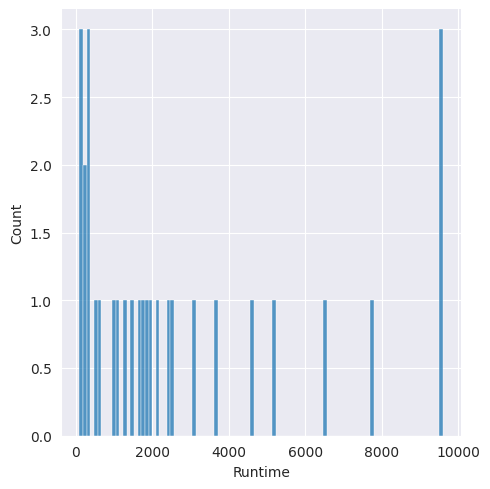

In [77]:
sns.displot(small_dataset, x="Runtime", bins=100)
print(small_dataset["Runtime"].describe())
print(small_dataset["Status"].value_counts())

In [76]:
import shutil
import os

from pathlib import Path
from dotenv import load_dotenv
load_dotenv()

new_loc = "./dataset_30/instances"
Path("./dataset_30/instances").mkdir(parents=True, exist_ok=True)


base_loc = os.getenv("INSTANCE_DIR")
print(base_loc)

for file_name in small_dataset["File"]:
    numba = os.path.basename(file_name)[:-4]
    # print(numba)
    shutil.copyfile(f"{base_loc}/mip_{numba}.lp", f"{new_loc}/mip_{numba}.lp")

/home/skippybal/Projects/Styx/aclib2/instances/mip/data/SDPdMLPa-MIPVerify
